In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score
import os
from sklearn.pipeline import Pipeline

In [72]:
pth = os.path.abspath(os.path.join(os.getcwd(), ".."))
pth = os.path.abspath(os.path.join(pth, "data/augmented"))
print(pth)  # Affiche le répertoire parent

c:\Users\DF6610\Challenge_tech\data\augmented


In [74]:
df_train = pd.read_csv(pth + "/train.csv")
df_val = pd.read_csv(pth + "/val.csv")
df_test = pd.read_csv("c:\\Users\\DF6610\\Challenge_tech\\data\\test.csv")

In [75]:
label_mapping={'out_of_scope': 0,
 'translate': 1,
 'book_flight': 2,
 'lost_luggage': 3,
 'travel_alert': 4,
 'travel_suggestion': 5,
 'carry_on': 6,
 'book_hotel': 7,
 'flight_status': 8}

In [76]:
X_train= df_train['text']
y_train = df_train['label'].map(label_mapping)

X_val = df_val['text']
y_val = df_val['label'].map(label_mapping)

X_test = df_test['text']
y_test = df_test['label'].map(label_mapping)



In [77]:
n = 5000 # Nombre de features à conserver
# Initialiser le vectoriseur TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=n)

# Apprendre le vocabulaire et transformer les textes
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)

In [78]:
# Initialiser et entraîner le modèle SVM
# Dictionnaire des poids de classes
class_weights = {0: 1.0, 1: 1.0, 2: 1.0, 3: 3.0, 4: 1.0, 5: 1.0, 6: 1.0, 7: 1.0, 8: 1.0}
svm_model = SVC(kernel='linear', random_state=42,class_weight=class_weights)
svm_model.fit(X_train_tfidf, y_train)


SVC(class_weight={0: 1.0, 1: 1.0, 2: 1.0, 3: 3.0, 4: 1.0, 5: 1.0, 6: 1.0,
                  7: 1.0, 8: 1.0},
    kernel='linear', random_state=42)

In [79]:
# Prédire sur l'ensemble de test
y_val_pred = svm_model.predict(X_val_tfidf)

# Afficher les résultats de classification
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.72      0.67      0.69        51
           1       0.25      0.14      0.18         7
           2       0.64      0.50      0.56        14
           3       0.56      0.90      0.69        21
           4       0.67      0.55      0.60        11
           5       0.27      0.14      0.19        21
           6       1.00      1.00      1.00        11
           7       0.71      1.00      0.83        20
           8       0.95      1.00      0.98        21

    accuracy                           0.69       177
   macro avg       0.64      0.66      0.64       177
weighted avg       0.66      0.69      0.67       177



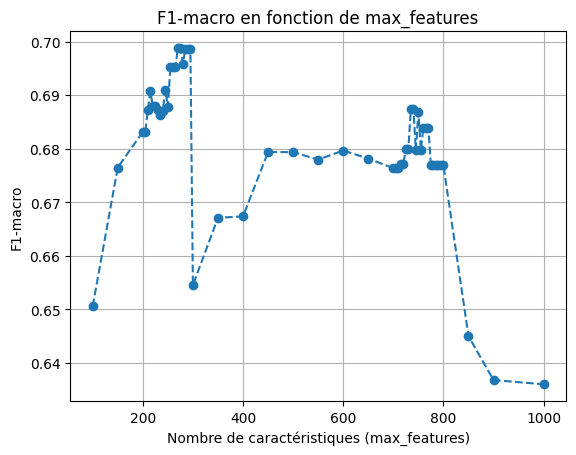

Meilleur nombre de caractéristiques (max_features) : 270
Meilleur F1-macro score : 0.698738206716243


In [80]:


# Paramètres à tester avec GridSearch
param_grid = {
    
    'max_features': [100,150,200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255, 260, 265, 270, 275, 280, 285, 290, 295, 300,350,400,450,500,550,600,650,700, 705, 710, 715, 720, 725, 730, 735, 740, 745, 750, 755, 760, 765, 770, 775, 780, 785, 790, 795, 800,850,900,1000]  # Différentes valeurs de n pour le TF-IDF
}


# Listes pour stocker les résultats
f1_scores = []
max_features_values = []

# Parcourir les différents paramètres de GridSearch
for max_feat in param_grid['max_features']:
    # Initialiser le vectoriseur TF-IDF avec un nombre de features (max_features)
    tfidf_vectorizer = TfidfVectorizer(max_features=max_feat)

    # Apprendre le vocabulaire et transformer les textes
    X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
    X_val_tfidf = tfidf_vectorizer.transform(X_val)

    # Initialiser et entraîner le modèle SVM avec les poids de classe
    svm_model = SVC(kernel='linear', random_state=42, class_weight=class_weights)
    svm_model.fit(X_train_tfidf, y_train)

    # Prédictions sur l'ensemble de validation
    y_val_pred = svm_model.predict(X_val_tfidf)

    # Calculer la F1-macro score
    f1 = f1_score(y_val, y_val_pred, average='macro')
    
    # Ajouter les résultats à nos listes
    f1_scores.append(f1)
    max_features_values.append(max_feat)

# Tracer les F1-scores en fonction de max_features
plt.plot(max_features_values, f1_scores, marker='o', linestyle='--')
plt.xlabel('Nombre de caractéristiques (max_features)')
plt.ylabel('F1-macro')
plt.title('F1-macro en fonction de max_features')
plt.grid(True)
plt.show()

# Résultats finaux
best_max_features = max_features_values[f1_scores.index(max(f1_scores))]
print(f"Meilleur nombre de caractéristiques (max_features) : {best_max_features}")
print(f"Meilleur F1-macro score : {max(f1_scores)}")


In [81]:
# Next step 

# Entrainelent des modèles avec les meilleurs paramètres sur et train et val 
# faire une méthode d'ensemble

In [82]:
df_train_full = pd.concat([df_train, df_val], ignore_index=True)
X_train_full = df_train_full['text']
y_train_full = df_train_full['label'].map(label_mapping)

In [85]:
n = 270 # Nombre de features à conserver
# Initialiser le vectoriseur TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=n)

# Apprendre le vocabulaire et transformer les textes
X_train_full_tfidf = tfidf_vectorizer.fit_transform(X_train_full)
X_test_tfidf = tfidf_vectorizer.transform(X_test)
# Initialiser et entraîner le modèle SVM
# Dictionnaire des poids de classes
class_weights = {0: 1.0, 1: 1.0, 2: 1.0, 3: 3.0, 4: 1.0, 5: 1.0, 6: 1.0, 7: 1.0, 8: 1.0}
svm_model = SVC(kernel='linear', random_state=42,class_weight=class_weights)
svm_model.fit(X_train_full_tfidf, y_train_full)

# Prédire sur l'ensemble de test
y_test_pred = svm_model.predict(X_test_tfidf)

# Afficher les résultats de classification
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.60      0.75      0.67         4
           1       0.33      1.00      0.50         1
           2       1.00      1.00      1.00         1
           3       0.50      1.00      0.67         1
           4       1.00      1.00      1.00         1
           5       1.00      0.50      0.67         2
           6       0.00      0.00      0.00         2
           7       1.00      0.50      0.67         2
           8       1.00      1.00      1.00         1

    accuracy                           0.67        15
   macro avg       0.71      0.75      0.69        15
weighted avg       0.68      0.67      0.63        15



c:\Users\DF6610\AppData\Local\anaconda3\envs\illuin\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\DF6610\AppData\Local\anaconda3\envs\illuin\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\DF6610\AppData\Local\anaconda3\envs\illuin\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f